In [3]:
import pandas as pd
import numpy as np
import re
import string

import nltk
import spacy

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')

# Load spaCy model
nlp = spacy.load("en_core_web_sm")

# Load Dataset
df = pd.read_csv("D:\Customer Support\Data set\customer_support_tickets_clean.csv")

# Combine text columns
df["text"] = (
    df["Ticket Subject"].fillna("") + " " +
    df["Ticket Description"].fillna("")
)

# Text Cleaning Function
def clean_text(text):

    text = str(text).lower()

    # Remove HTML
    text = re.sub(r'<.*?>', '', text)

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove digits
    text = re.sub(r'\d+', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["clean_text"] = df["text"].apply(clean_text)

# Stopwords
stop_words = set(stopwords.words("english"))

# Lemmatization Function
def preprocess_text(text):

    doc = nlp(text)

    tokens = [
        token.lemma_
        for token in doc
        if token.text not in stop_words
        and not token.is_punct
        and not token.is_space
    ]

    return " ".join(tokens)

df["processed_text"] = df["clean_text"].apply(
    preprocess_text
)

print(df[["text", "processed_text"]].head())

<>:18: SyntaxWarning: invalid escape sequence '\C'
<>:18: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Windows 10\AppData\Local\Temp\ipykernel_8304\2297327505.py:18: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Customer Support\Data set\customer_support_tickets_clean.csv")
[nltk_data] Downloading package stopwords to C:\Users\Windows
[nltk_data]     10\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


                                                text  \
0  Product setup I'm having an issue with the {pr...   
1  Peripheral compatibility I'm having an issue w...   
2  Network problem I'm facing a problem with my {...   
3  Account access I'm having an issue with the {p...   
4  Data loss I'm having an issue with the {produc...   

                                      processed_text  
0  product setup issue productpurchased please as...  
1  peripheral compatibility issue productpurchase...  
2  network problem face problem productpurchase p...  
3  account access issue productpurchased please a...  
4  data loss issue productpurchased please assist...  


In [4]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_tfidf = tfidf.fit_transform(
    df["processed_text"]
)

print("TF-IDF Shape:")
print(X_tfidf.shape)

TF-IDF Shape:
(8469, 5000)


In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

encoded = tokenizer(
    list(df["processed_text"][:10]),
    padding=True,
    truncation=True,
    max_length=128,
    return_tensors="pt"
)

print(encoded.keys())

KeysView({'input_ids': tensor([[  101,  4031, 16437,  3277,  4031,  5311, 26300,  2094,  3531,  6509,
         25640, 14101,  3642,  9120,  5227,  4037,  4769,  3531,  3313,  4638,
         10373,  4769,  3046, 13460, 23416,  3357,  5254,  5310,  6410,  3277,
         29486,   102,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0],
        [  101, 15965, 21778,  3277,  4031,  5311, 26300,  2094,  3531,  6509,
          2342,  2689,  4839,  4031,  3277,  4031,  5311, 26300,  2094,  3531,
          6509,  3277,  2227, 23852,  2823,  2147,  2986,  2051,  2552, 14153,
           102,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0],
        [  101,  2897,  3291,  2227,  3291,  4031,  5311, 26300,  4031,  5311,
         26300,  2094,  2735,  2147,  2986,  7483,  2025,  6869,  2428,  2224,
          2434,  3715,  2099,  2272,  4031,  5311, 26300,  2094,  3715,  7919,
           102,     0,     0,   

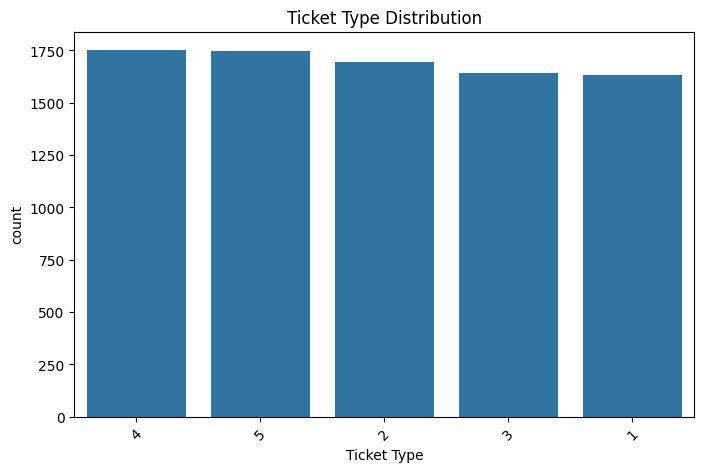

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ticket Type",
    order=df["Ticket Type"]
    .value_counts()
    .index
)

plt.title("Ticket Type Distribution")
plt.xticks(rotation=45)

plt.show()

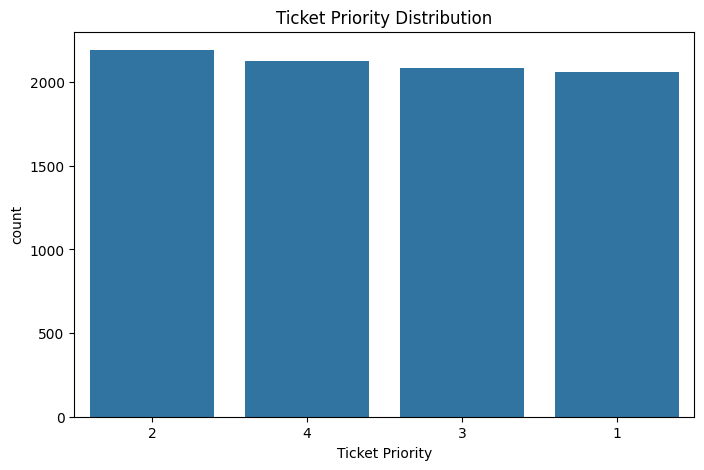

In [7]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ticket Priority",
    order=df["Ticket Priority"]
    .value_counts()
    .index
)

plt.title("Ticket Priority Distribution")

plt.show()

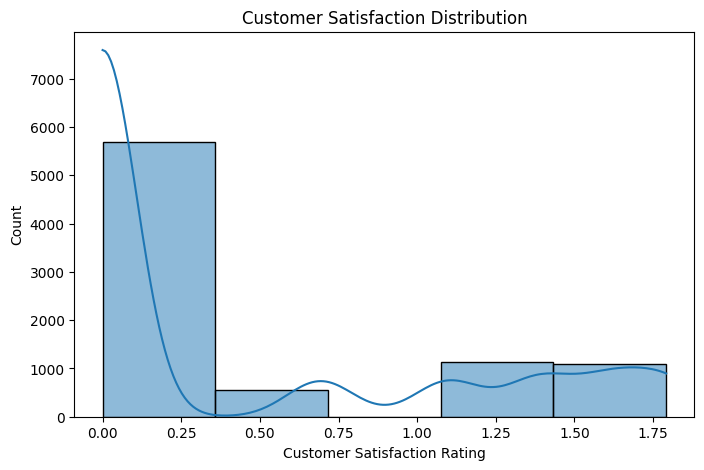

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Customer Satisfaction Rating"],
    bins=5,
    kde=True
)

plt.title(
    "Customer Satisfaction Distribution"
)

plt.show()

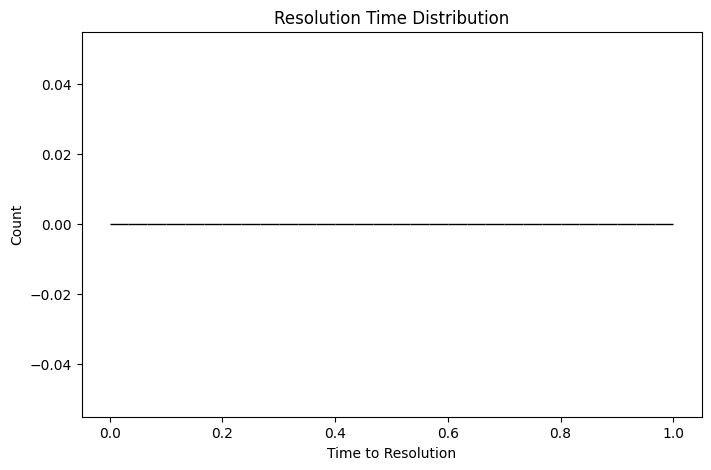

In [9]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["Time to Resolution"],
    bins=30,
    kde=True
)

plt.title(
    "Resolution Time Distribution"
)

plt.show()

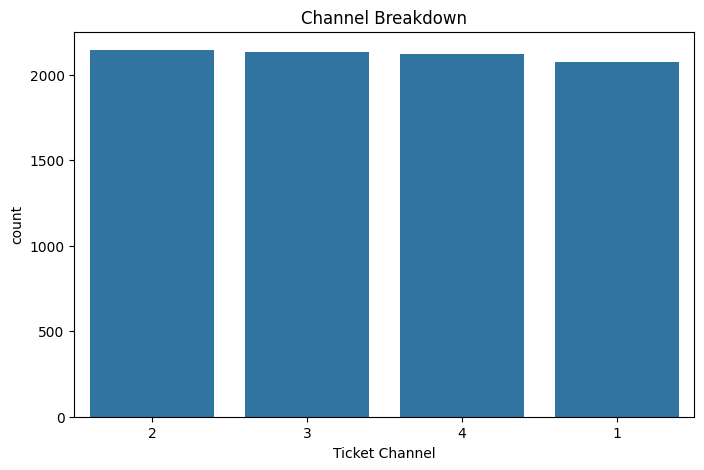

In [10]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Ticket Channel",
    order=df["Ticket Channel"]
    .value_counts()
    .index
)

plt.title("Channel Breakdown")

plt.show()

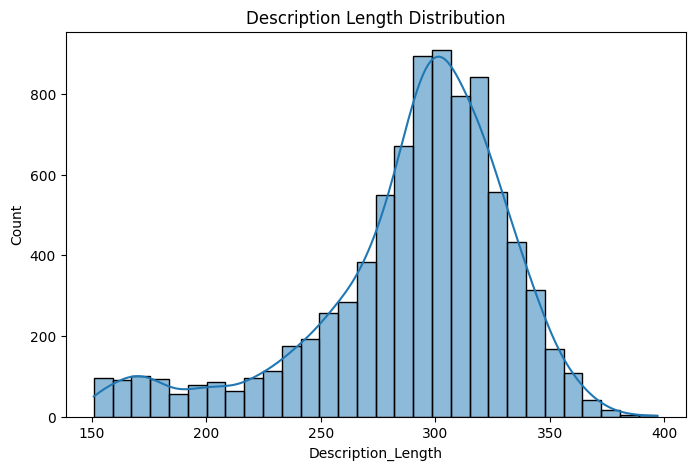

In [11]:
df["Description_Length"] = (
    df["Ticket Description"]
    .astype(str)
    .apply(len)
)

plt.figure(figsize=(8,5))

sns.histplot(
    df["Description_Length"],
    bins=30,
    kde=True
)

plt.title(
    "Description Length Distribution"
)

plt.show()

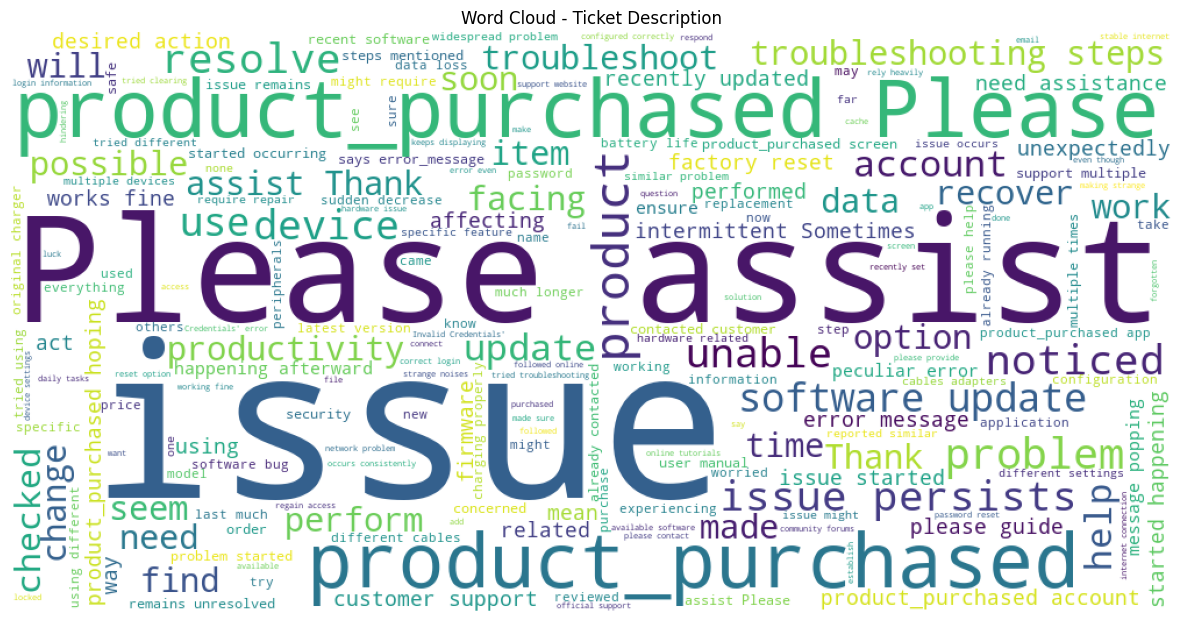

In [12]:
from wordcloud import WordCloud

text = " ".join(
    df["Ticket Description"]
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Word Cloud - Ticket Description"
)

plt.show()

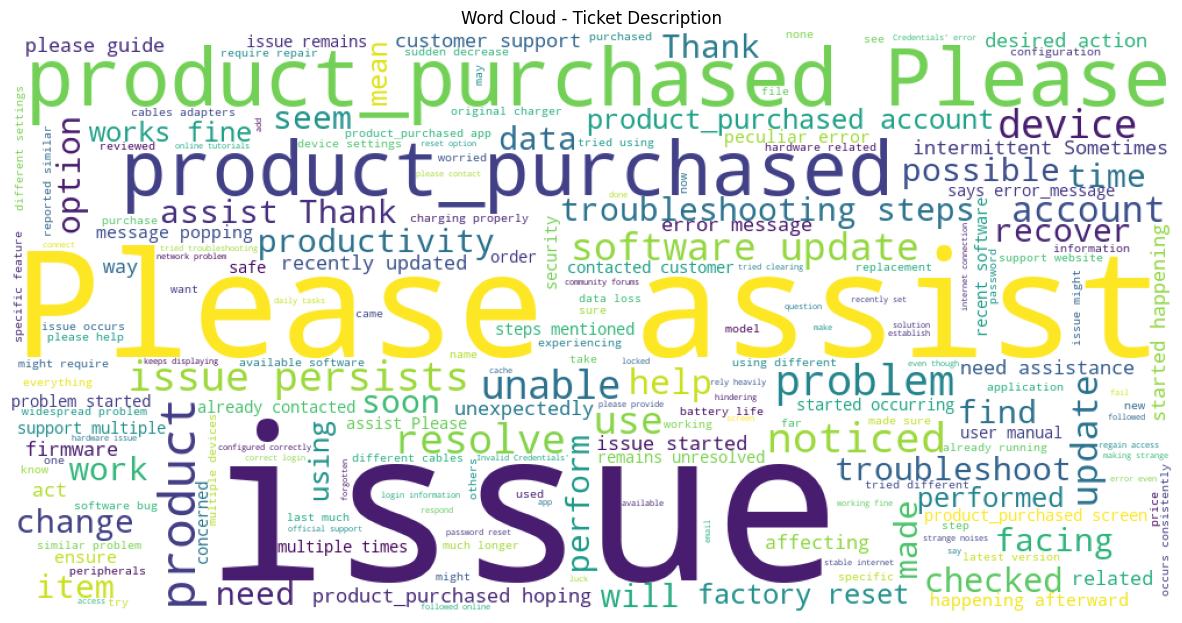

In [13]:
from wordcloud import WordCloud

text = " ".join(
    df["Ticket Description"]
    .dropna()
    .astype(str)
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,8))

plt.imshow(wordcloud)

plt.axis("off")

plt.title(
    "Word Cloud - Ticket Description"
)

plt.show()

In [14]:
print("\nTicket Type Distribution (%)")

print(
    round(
        df["Ticket Type"]
        .value_counts(normalize=True)
        * 100,
        2
    )
)

print("\nTicket Priority Distribution (%)")

print(
    round(
        df["Ticket Priority"]
        .value_counts(normalize=True)
        * 100,
        2
    )
)


Ticket Type Distribution (%)
Ticket Type
4    20.69
5    20.63
2    20.01
3    19.38
1    19.29
Name: proportion, dtype: float64

Ticket Priority Distribution (%)
Ticket Priority
2    25.88
4    25.14
3    24.62
1    24.36
Name: proportion, dtype: float64


In [15]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Ticket Type",
    color="Ticket Type",
    title="Interactive Ticket Type Distribution"
)

fig.show()

In [16]:
import plotly.express as px

fig = px.histogram(
    df,
    x="Ticket Type",
    color="Ticket Type",
    title="Interactive Ticket Type Distribution"
)

fig.show()